# Exploration des Données (EDA)

**Principaux objectifs :**
1. Quantifier les volumes réels par classe et par source.
2. Mettre en évidence les fusions de classes.
3. Analyser les déséquilibres critiques.
4. Etiduer la pertinence d'un *class weighting*.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

PROJECT_ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
LOGS_DIR = PROJECT_ROOT / "logs" / "preprocessing"
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.data.utils import class_name_mapping

## 1. Production d'un set exploratoire

In [10]:
corrupted_file = LOGS_DIR / "corrupted_images.txt"
corrupted_paths = set()
if corrupted_file.exists():
    with open(corrupted_file, "r") as f:
        corrupted_paths = set(line.strip() for line in f if line.strip())
print(f"Nombre d'images corrompues à ignorer : {len(corrupted_paths)}")

Nombre d'images corrompues à ignorer : 27


In [11]:
data_records = []

for file_path in RAW_DATA_DIR.rglob('*'):
    if file_path.is_file():
        rel_path_str = str(file_path.relative_to(PROJECT_ROOT))
        
        # Images corrompues ou marquées comme supprimées
        if rel_path_str in corrupted_paths or "x_Removed" in rel_path_str:
            continue
        
        # Source et classe d'origine
        parts = file_path.relative_to(RAW_DATA_DIR).parts
        if len(parts) >= 3:
            source = parts[0]
            crop = parts[1]
            orig_class = parts[2]
            
            mapping_key = f"{source}/{crop}/{orig_class}"
            final_class = class_name_mapping().get(mapping_key, "Unknown")
            
            if final_class != "Unknown":
                data_records.append({
                    "original_path": rel_path_str,
                    "source": source,
                    "crop": crop,
                    "final_class": final_class,
                    "extension": file_path.suffix.lower()
                })

In [13]:
df = pd.DataFrame(data_records)
print(f"Total d'images saines répertoriées : {len(df)}")

Total d'images saines répertoriées : 14055


*Nous avons $(14087 - 27) - 5 = 14055$*

In [14]:
df.sample(10)

,original_path,source,crop,final_class,extension
830,data/raw/CCMT/Cassava/bacterial blight/bacteri...,CCMT,Cassava,Cassava___Bacterial_Blight,.jpg
11021,data/raw/PlantVillage/Maize/Corn_(maize)___Com...,PlantVillage,Maize,Corn___Common_Rust,.jpg
8670,data/raw/CCMT/Maize/leaf spot/leaf spot155_.jpg,CCMT,Maize,Corn___Gray_Leaf_Spot,.jpg
806,data/raw/CCMT/Cassava/bacterial blight/bacteri...,CCMT,Cassava,Cassava___Bacterial_Blight,.jpg
12831,data/raw/PlantVillage/Maize/Corn_(maize)___Cer...,PlantVillage,Maize,Corn___Gray_Leaf_Spot,.jpg
13436,data/raw/PlantVillage/Maize/Corn_(maize)___Nor...,PlantVillage,Maize,Corn___Northern_Leaf_Blight,.jpg
6569,data/raw/CCMT/Maize/fall armyworm/fall armywor...,CCMT,Maize,Corn___Fall_Armyworm,.jpg
12762,data/raw/PlantVillage/Maize/Corn_(maize)___Cer...,PlantVillage,Maize,Corn___Gray_Leaf_Spot,.jpg
11409,data/raw/PlantVillage/Maize/Corn_(maize)___hea...,PlantVillage,Maize,Corn___Healthy,.jpg
610,data/raw/CCMT/Cassava/bacterial blight/bacteri...,CCMT,Cassava,Cassava___Bacterial_Blight,.jpg


## 2. Volumes et équilibre

In [15]:
class_counts = df['final_class'].value_counts().reset_index()
class_counts.columns = ['Classe', 'Nombre d\'images']

display(class_counts)

,Classe,Nombre d'images
0,Cassava___Bacterial_Blight,2614
1,Corn___Northern_Leaf_Blight,1983
2,Corn___Gray_Leaf_Spot,1762
3,Cassava___Brown_Spot,1481
4,Corn___Healthy,1368
5,Cassava___Mosaic,1205
6,Cassava___Healthy,1193
7,Corn___Common_Rust,1192
8,Corn___Streak_Virus,972
9,Corn___Fall_Armyworm,285


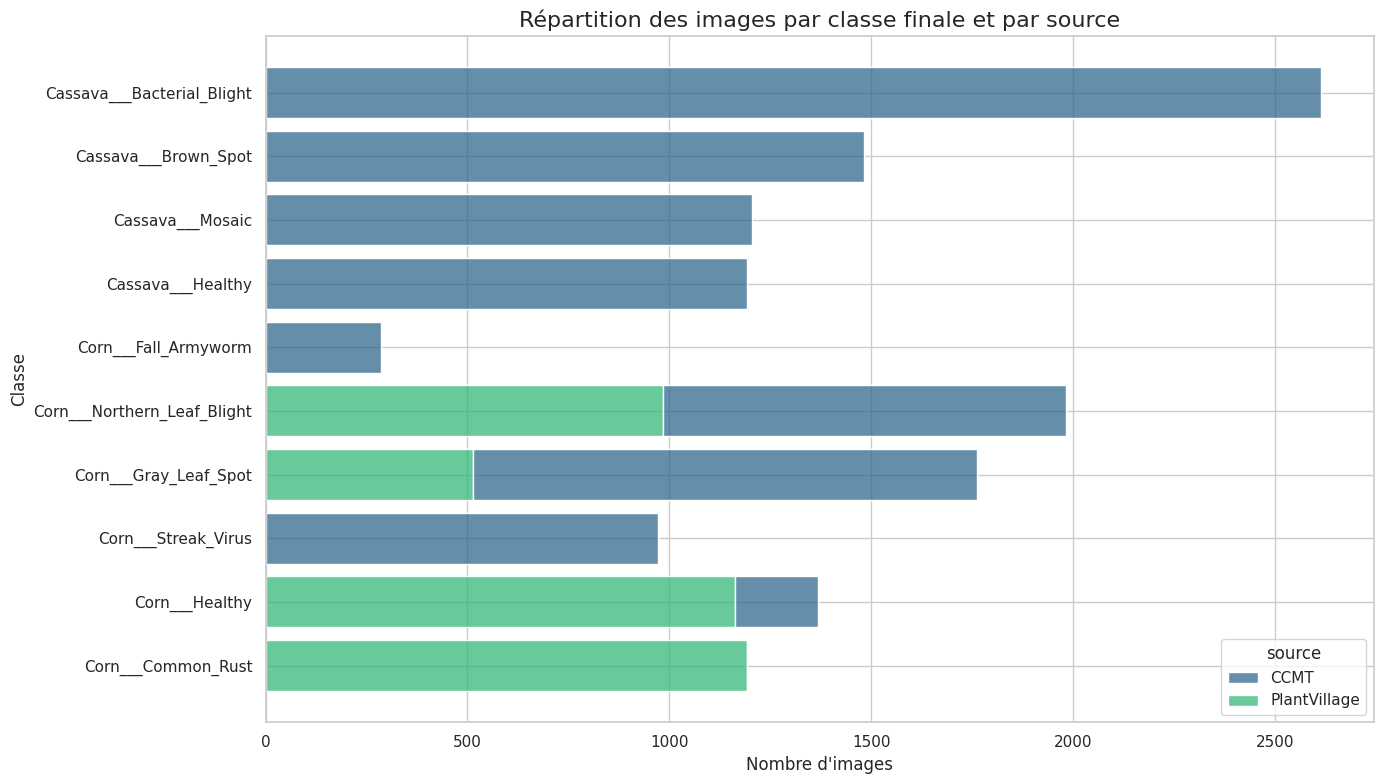

In [16]:
plt.figure(figsize=(14, 8))
sns.histplot(data=df, y='final_class', hue='source', multiple='stack', palette="viridis", shrink=.8)
plt.title("Répartition des images par classe finale et par source", fontsize=16)
plt.xlabel("Nombre d'images")
plt.ylabel("Classe")
plt.tight_layout()
plt.show()

#### 

*Cette figure me confirme que la classe *`Corn___Fall_Armyworm`* est très minoritaire. <br> Je vais donc voir si son ratio par rapport à la classe majoritaire nécessite une action d'équilibrage ou pas.*
> ***Si le ratio est de plus de 1:5, j'interviendrai.***

In [22]:
max_class = class_counts.iloc[0]["Nombre d\'images"]
min_class = class_counts.iloc[-1]['Nombre d\'images']
# min_class = df[df['final_class'] == 'Corn___Fall_Armyworm'].shape[0]

ratio = max_class / min_class
print(f"Ratio = 1:{ratio:.2f}")


Ratio = 1:9.17


Le ratio est quasiment de l'ordre de 1 contre 10. 

C'est trop. 

> J'utiliserai une méthode de gestion du désiquilibre sinon mon modèle sera extrèmement biaisé. <br> Je pense notamment à la pénalisation pondéré par rapport à l'effectif des classes : **class weighting**

In [26]:
for idx, row in class_counts.iterrows():
    print(f"{idx} - Ratio = 1:{class_counts.iloc[0]['Nombre d\'images'] / class_counts.iloc[idx]['Nombre d\'images'] :.2f}")

0 - Ratio = 1:1.00
1 - Ratio = 1:1.32
2 - Ratio = 1:1.48
3 - Ratio = 1:1.77
4 - Ratio = 1:1.91
5 - Ratio = 1:2.17
6 - Ratio = 1:2.19
7 - Ratio = 1:2.19
8 - Ratio = 1:2.69
9 - Ratio = 1:9.17


**Les autres sont jouables.**